# Baseline Technical Analysis — SMA Crossover with ATR Risk

This notebook establishes a **baseline** quantitative workflow for evaluating a technical
strategy across two distinct market groups (Forex and B3/Bovespa) and multiple
timeframes — so we can identify which horizon produces the best risk-adjusted edge.

1. **Load** every OHLC CSV from `../data/`, now organised into `forex/` and `b3/`
   subdirectories. Filenames follow `<ASSET>_<TF>_<START>_<END>.csv`.
2. **Prepare** multi-timeframe versions of each asset — different target timeframes
   are explored per group.
3. **Describe** a simple, fully-specified strategy (SMA crossover with ATR-based risk).
4. **Backtest** and compute standard performance metrics — **separately** for each
   group (Forex / B3) and each timeframe.
5. **Visualize** results with a dashboard (equity curve, drawdown, PnL distribution,
   rolling win rate).
6. **Optimize** parameters with **Walk-Forward Optimization** (WFO) — per group,
   per timeframe — and inspect stitched out-of-sample performance.
7. **Stress-test** robustness (Monte-Carlo shuffling and parameter-sensitivity sweeps)
   for each group's best-performing timeframe.

Heavy lifting lives in `../source/` so other notebooks can reuse the same components.

In [33]:
# Make the `source/` package importable from this notebook's location.
import sys
from pathlib import Path
from collections import Counter

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from source import (
    load_all,
    resample_ohlc,
    SMACrossoverStrategy,
    StrategyParams,
    Backtester,
    compute_metrics,
    metrics_table,
    plot_backtest_dashboard,
    plot_wfo_dashboard,
    plot_robustness_dashboard,
    walk_forward,
    WFOResult,
    monte_carlo_trades,
    monte_carlo_summary,
    parameter_sensitivity,
)

pd.set_option("display.float_format", "{:,.4f}".format)
plt.rcParams["figure.dpi"] = 110

## 1. Load the data

`load_all` scans both root-level CSVs **and** named subdirectories under `../data/`.
The subdirectory name (`forex`, `b3`, …) becomes each dataset's `group` tag.
Filename format: `<ASSET>_<TIMEFRAME>_<STARTYYYYMMDDHHMM>_<ENDYYYYMMDDHHMM>.csv`.

In [ ]:
datasets = load_all(REPO_ROOT / "data")
print(f"Loaded {len(datasets)} dataset(s):")
for (asset, tf), (meta, df) in datasets.items():
    group_tag = f"[{meta.group}]" if meta.group else "[root]"
    print(f"  {group_tag:8s} {asset} {tf}  rows={len(df):>8,}  {meta.start} -> {meta.end}")

# Split by group tag
forex_raw = {k: v for k, v in datasets.items() if v[0].group == "forex"}
b3_raw    = {k: v for k, v in datasets.items() if v[0].group == "b3"}

print(f"\nForex assets : {sorted(k[0] for k in forex_raw)}")
print(f"B3 assets    : {sorted(k[0] for k in b3_raw)}")

Incorrect Sep...
Incorrect Sep...
Incorrect Sep...
Incorrect Sep...
Incorrect Sep...
Incorrect Sep...
Incorrect Sep...
Incorrect Sep...


## 2. Multi-timeframe preparation

Different markets suit different analysis horizons:

| Group | Timeframes explored | Rationale |
|-------|---------------------|-----------|
| Forex | 1 h · 4 h · 1 D | 24/5 market; enough bars even at daily resolution |
| B3    | 1 min · 5 min · 15 min · 30 min | ~8 h session/day; daily bars would be too sparse |

Each M1 dataset is resampled to every target timeframe. Results in Sections 3–5 show
which horizon produces the best risk-adjusted edge per group.

In [ ]:
GROUP_TIMEFRAMES = {
    "forex": ["1h", "4h", "1D"],
    "b3":    ["1min", "5min", "15min", "30min"],
}


def build_asset_tfs(raw_datasets, target_tfs):
    """Resample all assets to every target TF.  Returns {tf: {asset: df}}."""
    out = {}
    for tf in target_tfs:
        out[tf] = {}
        for (asset, src_tf), (meta, df_raw) in raw_datasets.items():
            out[tf][asset] = (
                resample_ohlc(df_raw, tf)
                if meta.timeframe.upper() in {"M1", "M5", "M15", "M30"}
                else df_raw
            )
    return out


forex_tfs = build_asset_tfs(forex_raw, GROUP_TIMEFRAMES["forex"])
b3_tfs    = build_asset_tfs(b3_raw,    GROUP_TIMEFRAMES["b3"])

group_tfs = {"forex": forex_tfs, "b3": b3_tfs}

for group, tfs in group_tfs.items():
    print(f"\n{group.upper()}:")
    for tf, assets in tfs.items():
        for asset, df in assets.items():
            print(
                f"  {tf:6s}  {asset}  {len(df):>8,} bars"
                f"  ({df.index[0].date()} -> {df.index[-1].date()})"
            )


FOREX:
  1h      EURCAD    62,351 bars  (2016-04-11 -> 2026-04-21)
  1h      EURUSD    62,346 bars  (2016-04-11 -> 2026-04-21)
  1h      GBPCHF    62,342 bars  (2016-04-11 -> 2026-04-21)
  4h      EURCAD    15,616 bars  (2016-04-11 -> 2026-04-21)
  4h      EURUSD    15,615 bars  (2016-04-11 -> 2026-04-21)
  4h      GBPCHF    15,615 bars  (2016-04-11 -> 2026-04-21)
  1D      EURCAD     2,609 bars  (2016-04-11 -> 2026-04-21)
  1D      EURUSD     2,609 bars  (2016-04-11 -> 2026-04-21)
  1D      GBPCHF     2,609 bars  (2016-04-11 -> 2026-04-21)

B3:
  1min    WDO   695,501 bars  (2021-04-30 -> 2026-04-29)
  1min    WIN   689,104 bars  (2021-04-30 -> 2026-04-29)
  5min    WDO   139,143 bars  (2021-04-30 -> 2026-04-29)
  5min    WIN   137,896 bars  (2021-04-30 -> 2026-04-29)
  15min   WDO    46,388 bars  (2021-04-30 -> 2026-04-29)
  15min   WIN    46,385 bars  (2021-04-30 -> 2026-04-29)
  30min   WDO    23,197 bars  (2021-04-30 -> 2026-04-29)
  30min   WIN    23,194 bars  (2021-04-30 -> 202

## 3. Strategy definition — SMA crossover with ATR-based risk

**Entry**
- Long when the fast SMA crosses above the slow SMA (bar close).
- Short when the fast SMA crosses below the slow SMA.

**Exit**
- Hard stop loss: `entry − direction × sl_atr_mult × ATR`.
- Take profit:    `entry + direction × tp_atr_mult × ATR`.
- Reverse on the opposite crossover.

**Risk plan**
- One unit per trade; PnL in price points.
- Intrabar priority: stop loss before take profit (pessimistic assumption).
- No pyramiding; always flat between signals.

Baseline parameters are the same across all timeframes and groups — WFO in Section 4
will find the per-(group, timeframe) optimal values.

In [ ]:
baseline_params = StrategyParams(
    fast=20,
    slow=50,
    atr_period=14,
    sl_atr_mult=2.0,
    tp_atr_mult=3.0,
)

SUMMARY_METRICS = [
    "num_trades", "total_pnl", "win_rate", "profit_factor",
    "expectancy", "max_drawdown", "sharpe_daily", "sharpe_per_trade", "p_value",
]


class _PortfolioResult:
    """Lightweight result container for a combined multi-asset portfolio."""
    def __init__(self, trades, equity):
        self.trades = trades
        self.equity = equity


def build_portfolio(per_asset_results):
    """Merge per-asset BacktestResult objects into a single portfolio."""
    frames = []
    for asset, result in per_asset_results.items():
        if not result.trades.empty:
            t = result.trades.copy()
            t.insert(0, "asset", asset)
            frames.append(t)
    if not frames:
        return _PortfolioResult(pd.DataFrame(), pd.Series(dtype=float))
    combined = (
        pd.concat(frames, ignore_index=True)
        .sort_values("exit_time")
        .reset_index(drop=True)
    )
    equity = pd.Series(
        combined["pnl_points"].cumsum().values,
        index=pd.to_datetime(combined["exit_time"].values),
        name="equity_points",
    )
    return _PortfolioResult(combined, equity)


def run_baseline(asset_dfs, params, slippage=0.0):
    """Backtest all assets; return (per_asset dict, combined portfolio)."""
    per_asset = {
        asset: Backtester(SMACrossoverStrategy(params), slippage_points=slippage).run(df)
        for asset, df in asset_dfs.items()
    }
    return per_asset, build_portfolio(per_asset)


def metrics_comparison(portfolio_dict, keys=None):
    """Compare portfolio metrics across TFs. Columns = TFs, rows = metrics."""
    keys = keys or SUMMARY_METRICS
    rows = {}
    for tf, portfolio in portfolio_dict.items():
        m = compute_metrics(portfolio)
        rows[tf] = {k: m[k] for k in keys if k in m}
    return pd.DataFrame(rows)

In [ ]:
baseline_per_asset = {}   # [group][tf][asset] = BacktestResult
baseline_portfolio = {}   # [group][tf]         = _PortfolioResult

for group, tfs in group_tfs.items():
    baseline_per_asset[group] = {}
    baseline_portfolio[group] = {}
    for tf, asset_dfs in tfs.items():
        per_asset, portfolio = run_baseline(asset_dfs, baseline_params)
        baseline_per_asset[group][tf] = per_asset
        baseline_portfolio[group][tf] = portfolio
        n = len(portfolio.trades) if not portfolio.trades.empty else 0
        print(f"{group:5s}  {tf:6s}  {n:>6,} trades")

forex  1h       4,193 trades
forex  4h       1,106 trades
forex  1D         192 trades
b3     1min    31,989 trades
b3     5min     6,247 trades
b3     15min    2,100 trades
b3     30min      992 trades


### 3.1 Forex — baseline across timeframes

Portfolio metrics (all Forex assets combined) for each target timeframe, followed by a
per-asset breakdown and equity-curve dashboards.

In [ ]:
print("Portfolio metrics — Forex (all assets combined, per timeframe):")
display(metrics_comparison(baseline_portfolio["forex"]))

print("\nPer-asset breakdown by timeframe:")
for tf, asset_results in baseline_per_asset["forex"].items():
    print(f"\n  {tf}:")
    detail = {asset: compute_metrics(r) for asset, r in asset_results.items()}
    display(
        pd.DataFrame(detail).loc[
            ["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "max_drawdown"]
        ]
    )

Portfolio metrics — Forex (all assets combined, per timeframe):


,1h,4h,1D
num_trades,"4,193.0000","1,106.0000",192.0000
total_pnl,-0.5551,-0.1526,-0.8086
win_rate,0.3866,0.3843,0.3021
profit_factor,0.9305,0.9634,0.6320
expectancy,-0.0001,-0.0001,-0.0042
max_drawdown,-0.5771,-0.4764,-0.7955
sharpe_daily,-0.4925,-0.1363,-0.7363
sharpe_per_trade,-2.0333,-0.5554,-2.9468
p_value,0.0420,0.5786,0.0032



Per-asset breakdown by timeframe:

  1h:


,EURCAD,EURUSD,GBPCHF
num_trades,"1,414.0000","1,374.0000","1,405.0000"
total_pnl,-0.3404,0.0953,-0.3100
sharpe_daily,-0.4948,0.1882,-0.4925
profit_factor,0.8885,1.0453,0.8904
max_drawdown,-0.3498,-0.1402,-0.3560



  4h:


,EURCAD,EURUSD,GBPCHF
num_trades,384.0000,371.0000,351.0000
total_pnl,-0.3330,0.0605,0.1200
sharpe_daily,-0.4962,0.1160,0.1940
profit_factor,0.8053,1.0512,1.0937
max_drawdown,-0.3700,-0.1715,-0.1422



  1D:


,EURCAD,EURUSD,GBPCHF
num_trades,68.0000,58.0000,66.0000
total_pnl,-0.3434,-0.0653,-0.3999
sharpe_daily,-0.5280,-0.1258,-0.5994
profit_factor,0.5818,0.8723,0.5379
max_drawdown,-0.3641,-0.1491,-0.4347


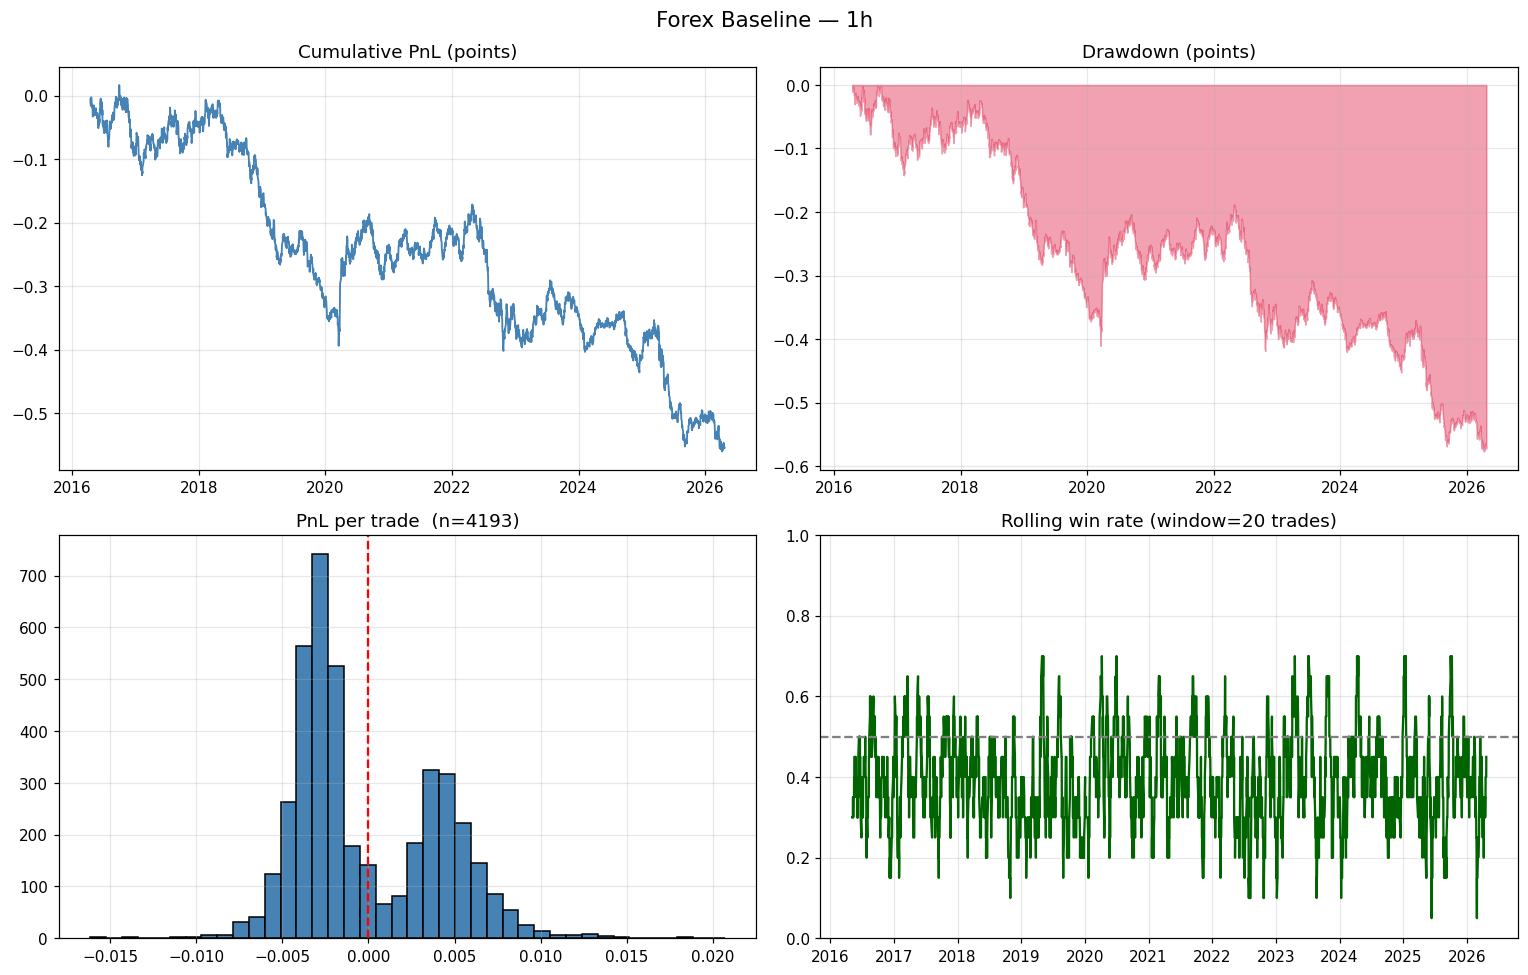

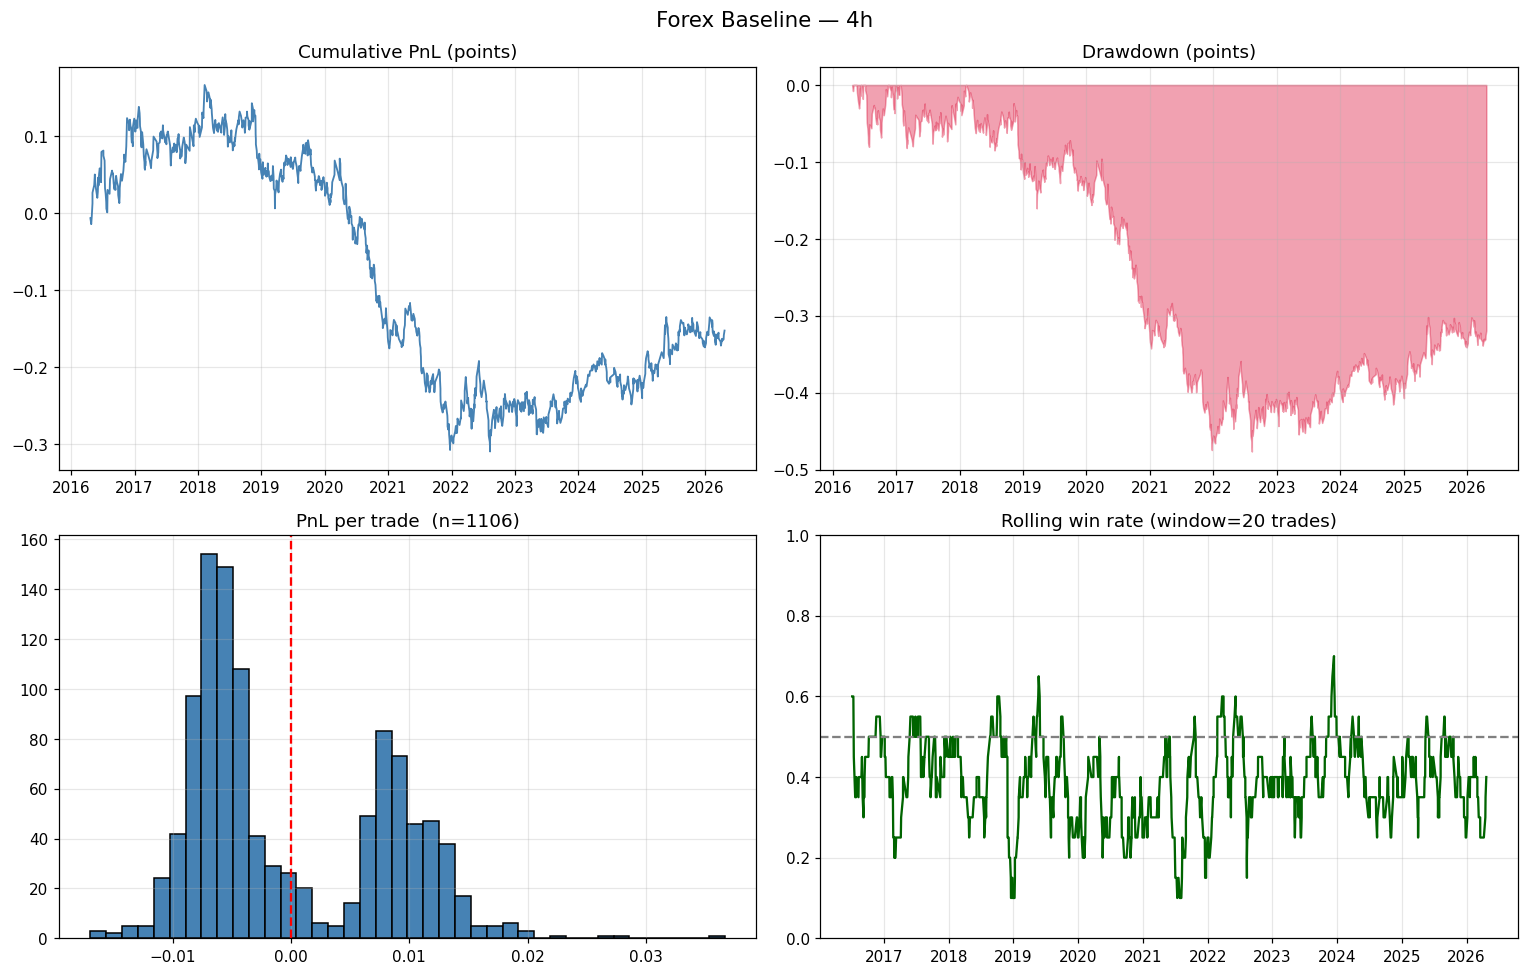

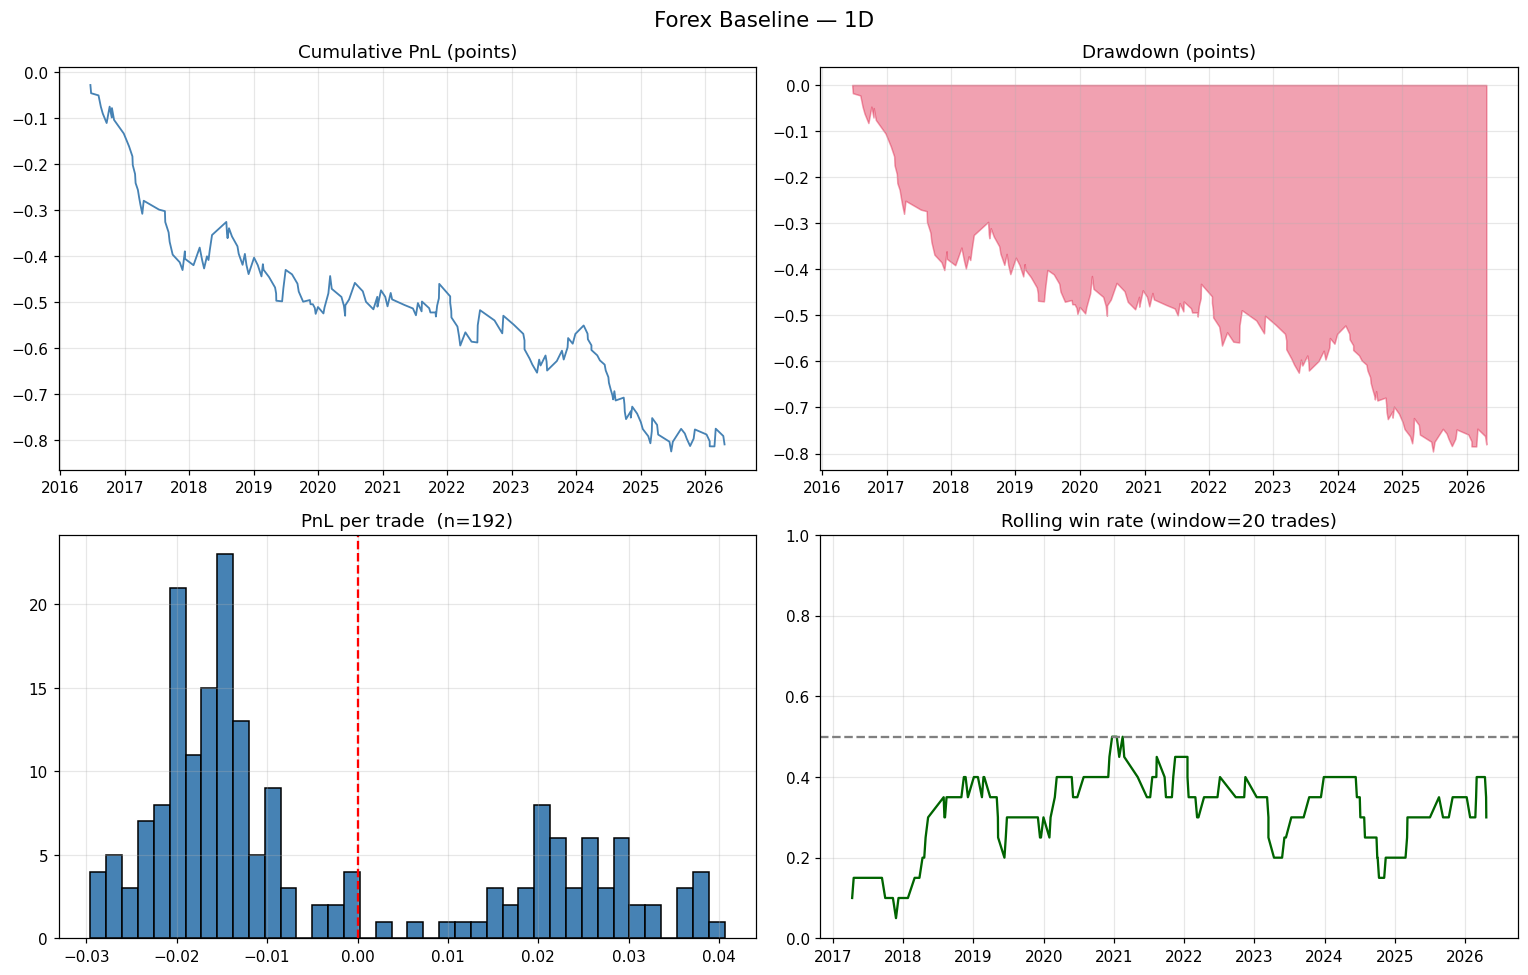

In [ ]:
for tf, portfolio in baseline_portfolio["forex"].items():
    if portfolio.trades.empty:
        print(f"  {tf}: no trades — skipping")
        continue
    fig = plot_backtest_dashboard(portfolio, title=f"Forex Baseline — {tf}")
    plt.show()

### 3.2 B3 — baseline across timeframes

Same layout for B3 (Bovespa) assets (WDO / WIN futures).

In [ ]:
print("Portfolio metrics — B3 (all assets combined, per timeframe):")
display(metrics_comparison(baseline_portfolio["b3"]))

print("\nPer-asset breakdown by timeframe:")
for tf, asset_results in baseline_per_asset["b3"].items():
    print(f"\n  {tf}:")
    detail = {asset: compute_metrics(r) for asset, r in asset_results.items()}
    display(
        pd.DataFrame(detail).loc[
            ["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "max_drawdown"]
        ]
    )

Portfolio metrics — B3 (all assets combined, per timeframe):


,1min,5min,15min,30min
num_trades,"31,989.0000","6,247.0000","2,100.0000",992.0000
total_pnl,"-31,314.5979","14,746.2696","-3,645.4576","-4,467.3764"
win_rate,0.3868,0.3972,0.3852,0.4002
profit_factor,0.9828,1.0182,0.9929,0.9867
expectancy,-0.9789,2.3605,-1.7359,-4.5034
max_drawdown,"-56,858.8929","-19,256.0384","-40,835.9753","-27,661.8280"
sharpe_daily,-0.3635,0.1579,-0.0374,-0.0509
sharpe_per_trade,-0.9325,0.4390,-0.1033,-0.1362
p_value,0.3511,0.6607,0.9177,0.8916



Per-asset breakdown by timeframe:

  1min:


,WDO,WIN
num_trades,"16,144.0000","15,845.0000"
total_pnl,"-1,450.5979","-29,864.0000"
sharpe_daily,-0.4987,-0.3495
profit_factor,0.9736,0.9831
max_drawdown,"-2,380.4684","-55,155.6429"



  5min:


,WDO,WIN
num_trades,"3,119.0000","3,128.0000"
total_pnl,-580.0161,"15,326.2857"
sharpe_daily,-0.1974,0.1645
profit_factor,0.9760,1.0195
max_drawdown,"-1,564.9219","-19,641.0000"



  15min:


,WDO,WIN
num_trades,"1,044.0000","1,056.0000"
total_pnl,"-2,185.4576","-1,460.0000"
sharpe_daily,-0.7718,-0.0152
profit_factor,0.8577,0.9971
max_drawdown,"-2,187.4726","-39,677.2857"



  30min:


,WDO,WIN
num_trades,516.0000,476.0000
total_pnl,"1,449.9808","-5,917.3571"
sharpe_daily,0.5371,-0.0664
profit_factor,1.1560,0.9819
max_drawdown,-919.0154,"-29,615.6429"


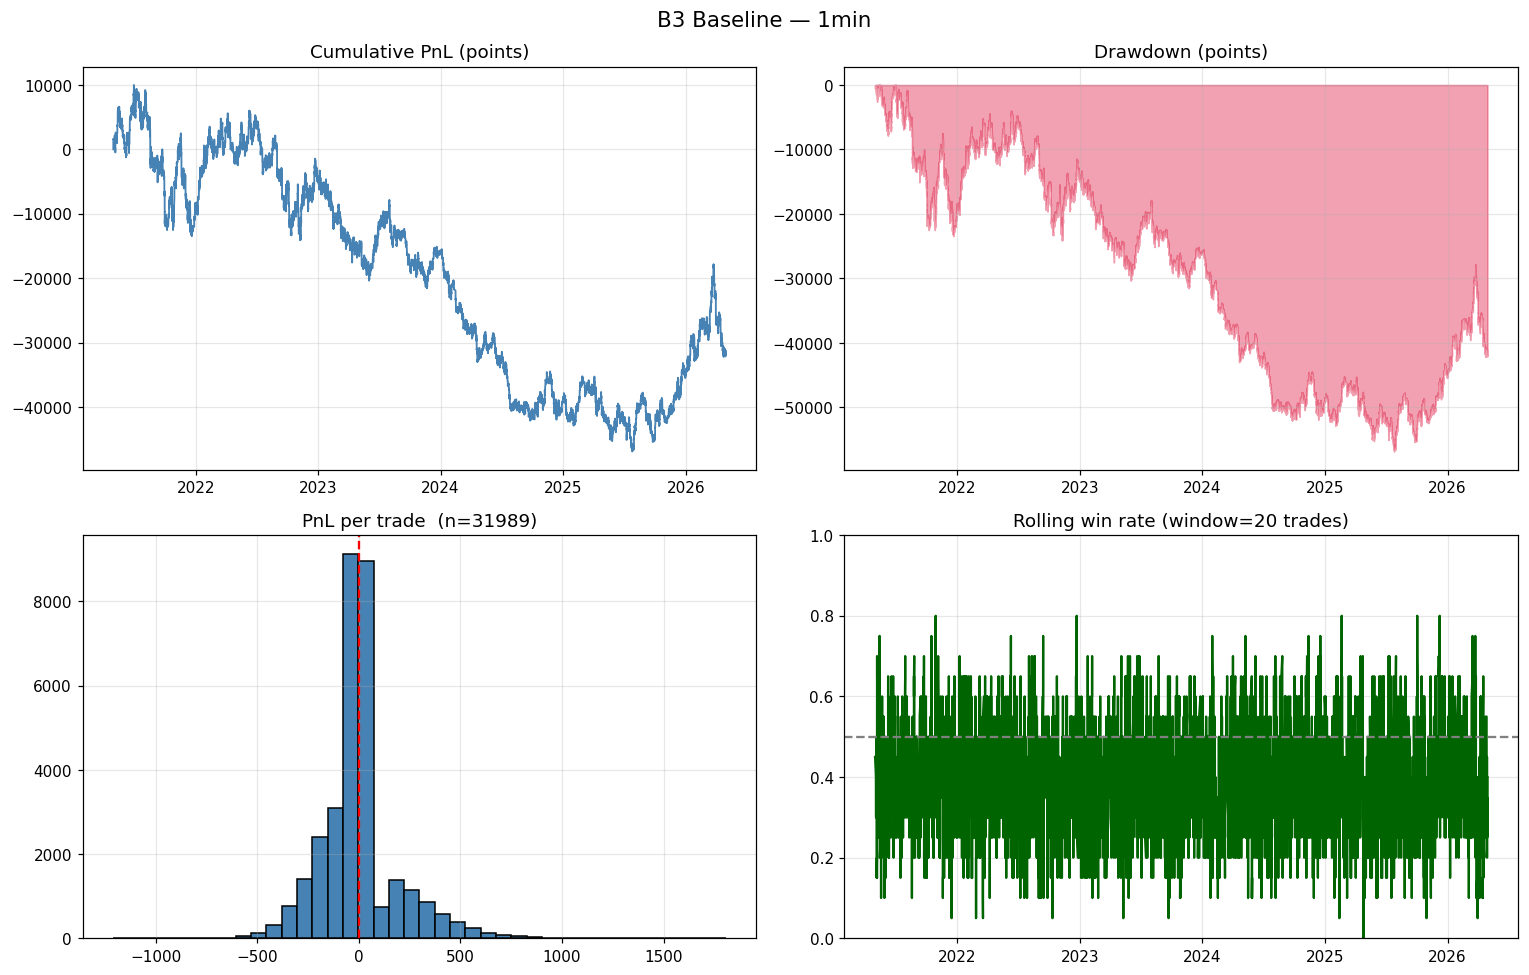

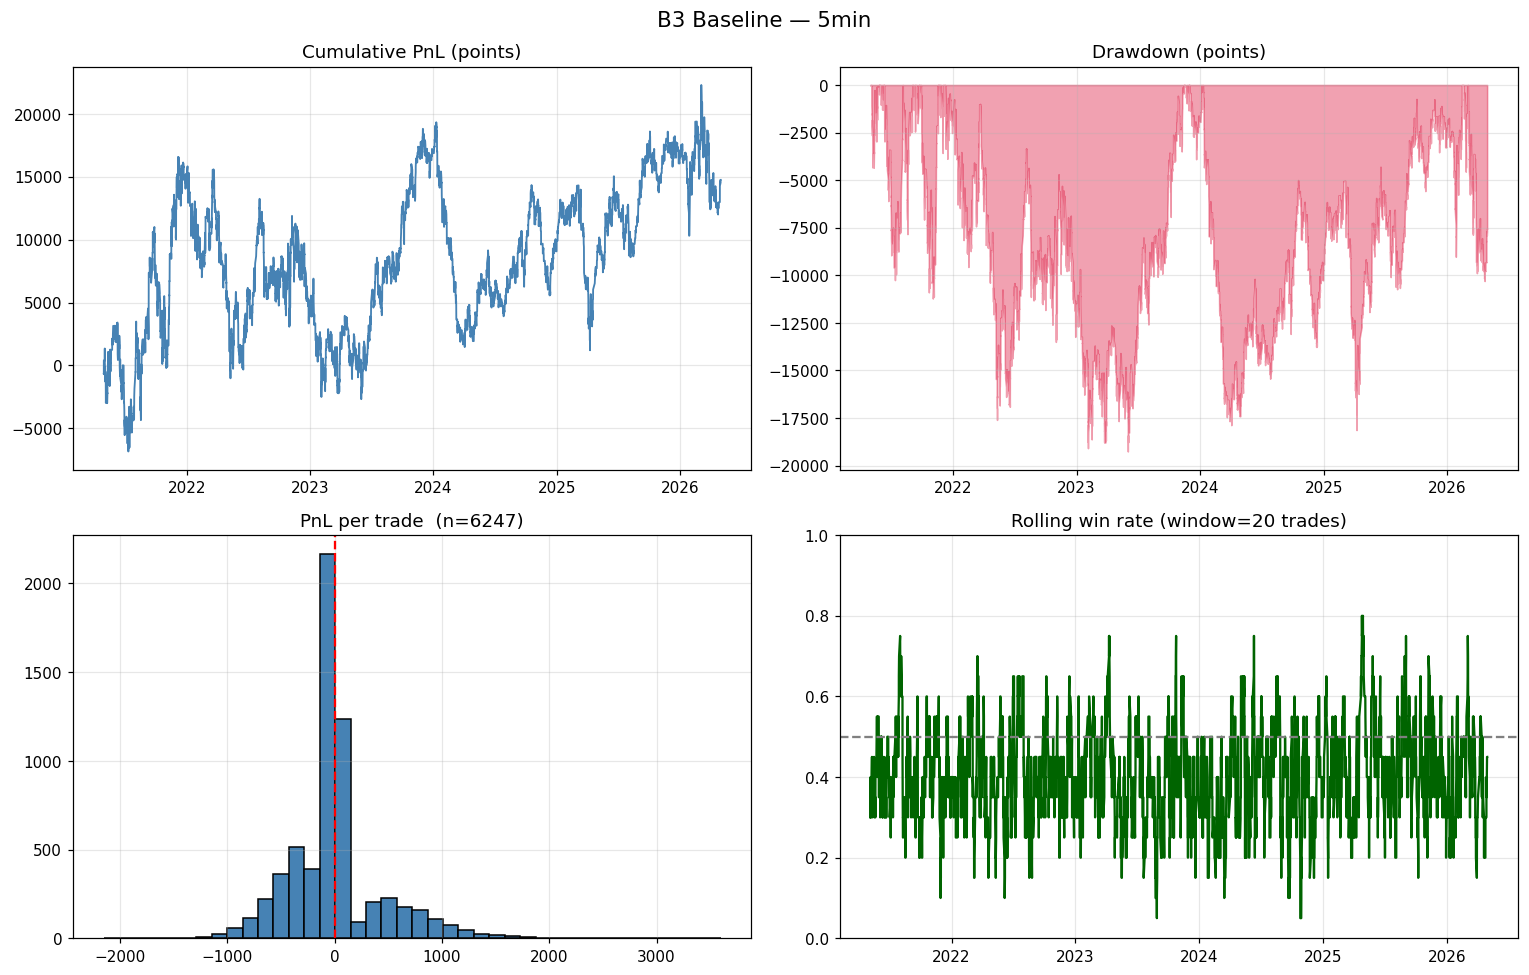

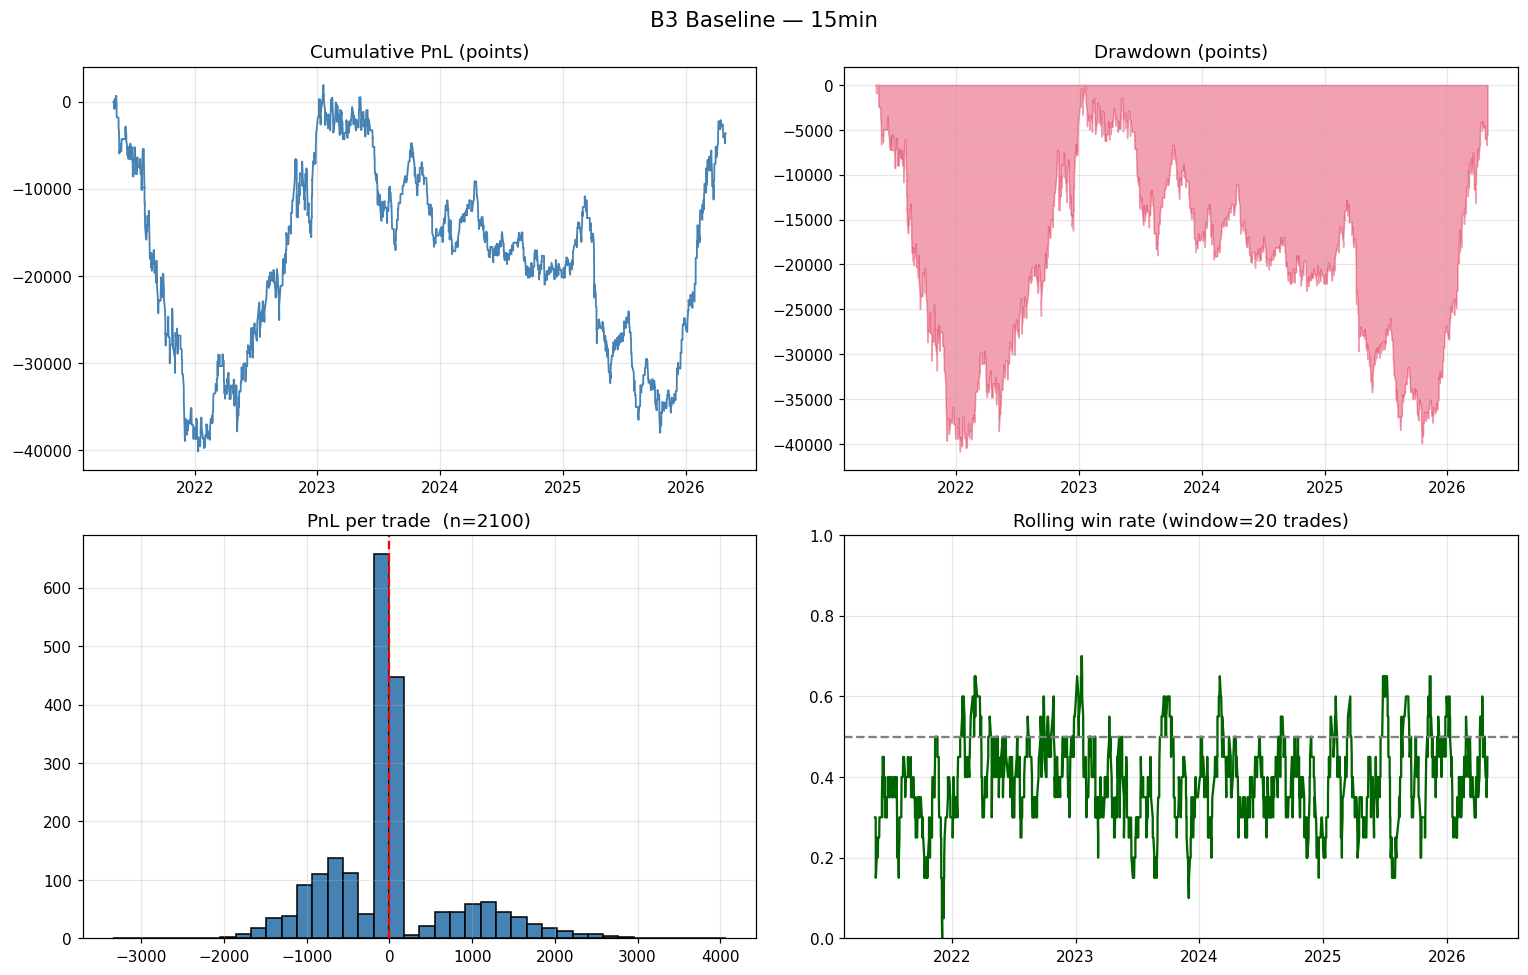

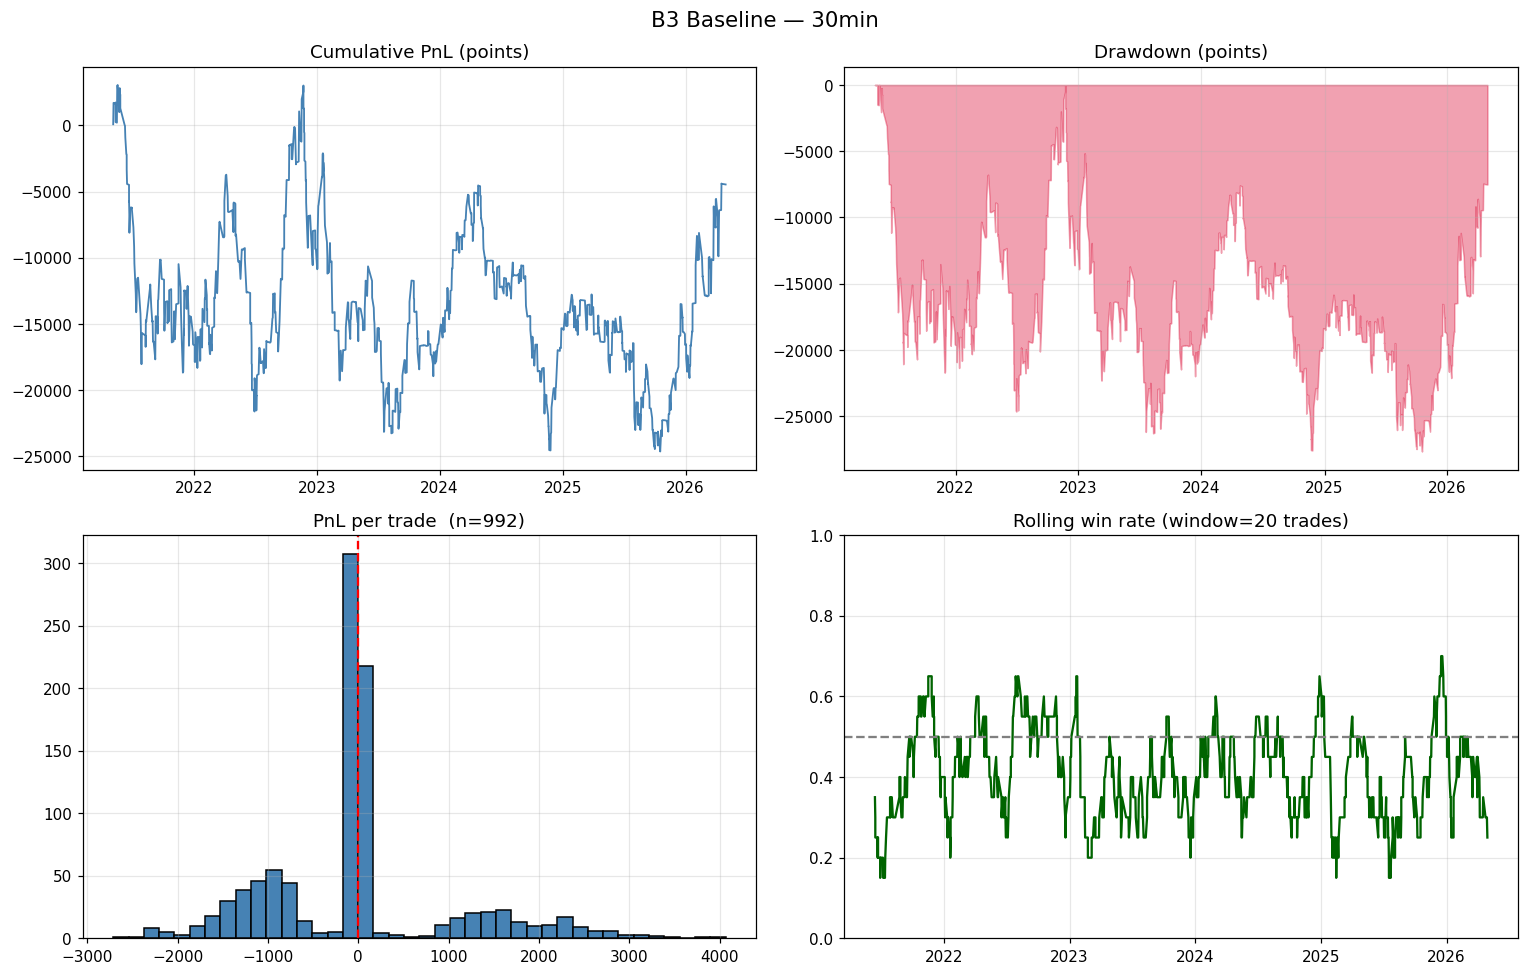

In [ ]:
for tf, portfolio in baseline_portfolio["b3"].items():
    if portfolio.trades.empty:
        print(f"  {tf}: no trades — skipping")
        continue
    fig = plot_backtest_dashboard(portfolio, title=f"B3 Baseline — {tf}")
    plt.show()

## 4. Walk-Forward Optimization

Each (group, timeframe) pair runs a separate WFO with `n_splits=5` equal folds.
Inside each fold:
- **In-sample** (75 %): grid-search parameters to maximise daily Sharpe.
- **Out-of-sample** (25 %): apply chosen parameters on unseen data.

OOS equity curves from all assets in the group are stitched chronologically,
giving an honest multi-asset out-of-sample picture per timeframe.

In [ ]:
param_grid = {
    "fast":        [5, 10, 20, 30, 50],
    "slow":        [40, 60, 100, 150, 200],
    "sl_atr_mult": [1.0, 1.5, 2.0, 2.5, 3.0],
    "tp_atr_mult": [1.5, 2.0, 3.0, 4.0, 5.0],
}


def build_combined_wfo(wfo_per_asset_tf):
    """Merge per-asset WFOResults into a single combined WFOResult."""
    _oos_frames = []
    for asset, wfo in wfo_per_asset_tf.items():
        if not wfo.oos_trades.empty:
            t = wfo.oos_trades.copy()
            t.insert(0, "asset", asset)
            _oos_frames.append(t)
    if not _oos_frames:
        return WFOResult(
            windows=pd.DataFrame(),
            oos_equity=pd.Series(dtype=float),
            oos_trades=pd.DataFrame(),
        )
    combined_oos = (
        pd.concat(_oos_frames, ignore_index=True)
        .sort_values("exit_time")
        .reset_index(drop=True)
    )
    oos_equity = pd.Series(
        combined_oos["pnl_points"].cumsum().values,
        index=pd.to_datetime(combined_oos["exit_time"].values),
        name="equity_points",
    )
    # Build per-fold summary rows (timestamps from first asset's WFO windows)
    sample_wfo = next(iter(wfo_per_asset_tf.values()))
    fold_rows = []
    if "fold" in combined_oos.columns and not sample_wfo.windows.empty:
        for fold_num in sorted(combined_oos["fold"].unique()):
            _ft = combined_oos[combined_oos["fold"] == fold_num].sort_values("exit_time")
            _feq = pd.Series(
                _ft["pnl_points"].cumsum().values,
                index=pd.to_datetime(_ft["exit_time"].values),
            )
            _fm = compute_metrics(_PortfolioResult(_ft, _feq))
            _bnd = sample_wfo.windows[sample_wfo.windows["fold"] == fold_num].iloc[0]
            param_cols = {k: v for k, v in _bnd.items() if str(k).startswith("param_")}
            fold_rows.append({
                "fold": fold_num,
                "is_start": _bnd["is_start"],  "is_end": _bnd["is_end"],
                "oos_start": _bnd["oos_start"], "oos_end": _bnd["oos_end"],
                "oos_pnl": _fm["total_pnl"],    "oos_sharpe": _fm["sharpe_daily"],
                "oos_profit_factor": _fm["profit_factor"],
                "oos_win_rate": _fm["win_rate"], "oos_trades": _fm["num_trades"],
                **param_cols,
            })
    return WFOResult(
        windows=pd.DataFrame(fold_rows),
        oos_equity=oos_equity,
        oos_trades=combined_oos,
    )


wfo_per_asset = {}   # [group][tf][asset] = WFOResult
wfo_combined  = {}   # [group][tf]         = WFOResult (merged OOS)

for group, tfs in group_tfs.items():
    wfo_per_asset[group] = {}
    wfo_combined[group]  = {}
    for tf, asset_dfs in tfs.items():
        wfo_per_asset[group][tf] = {}
        print(f"WFO {group} {tf} ...", end="  ", flush=True)
        for asset, df in asset_dfs.items():
            wfo_per_asset[group][tf][asset] = walk_forward(
                df, param_grid=param_grid, n_splits=5, oos_ratio=0.25
            )
        wfo_combined[group][tf] = build_combined_wfo(wfo_per_asset[group][tf])
        n_oos = len(wfo_combined[group][tf].oos_trades)
        print(f"{n_oos} OOS trades")

### 4.1 Forex — WFO out-of-sample results

OOS portfolio metrics — Forex (per timeframe):


,1h,4h,1D
num_trades,964.0000,254.0000,43.0000
total_pnl,-0.0528,0.0425,-0.0161
win_rate,0.4533,0.4409,0.4419
profit_factor,0.9675,1.0537,0.9445
expectancy,-0.0001,0.0002,-0.0004
max_drawdown,-0.1184,-0.0540,-0.1228
sharpe_daily,-0.1206,0.1203,-0.1245
sharpe_per_trade,-0.4238,0.3642,-0.1532
p_value,0.6717,0.7157,0.8782


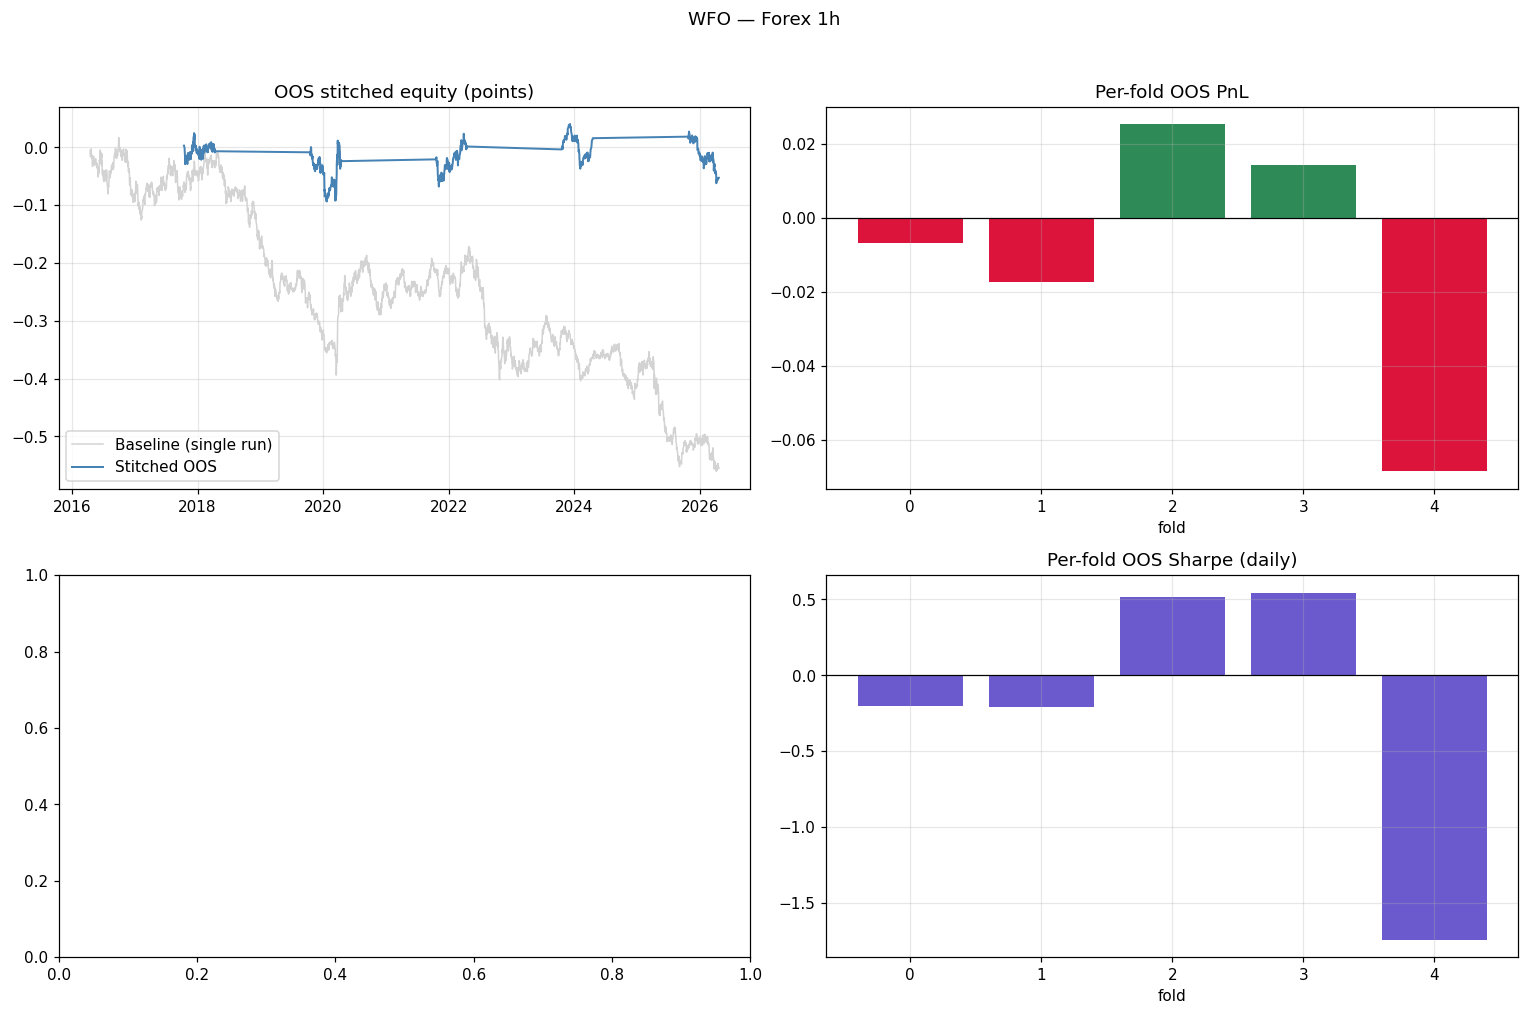

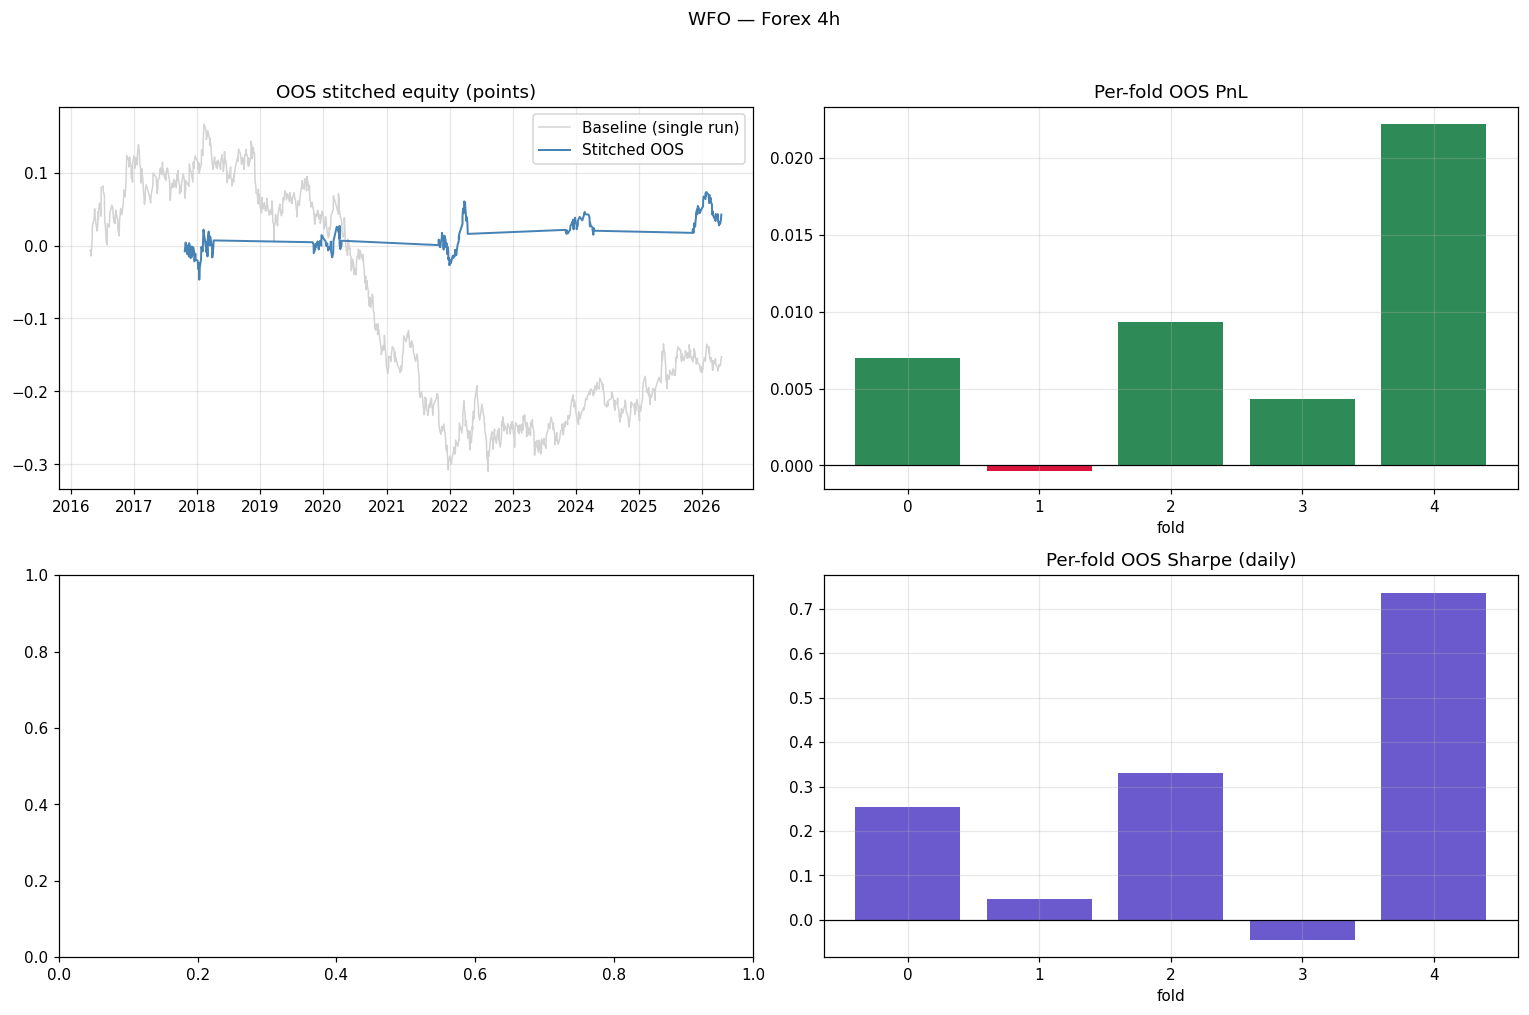

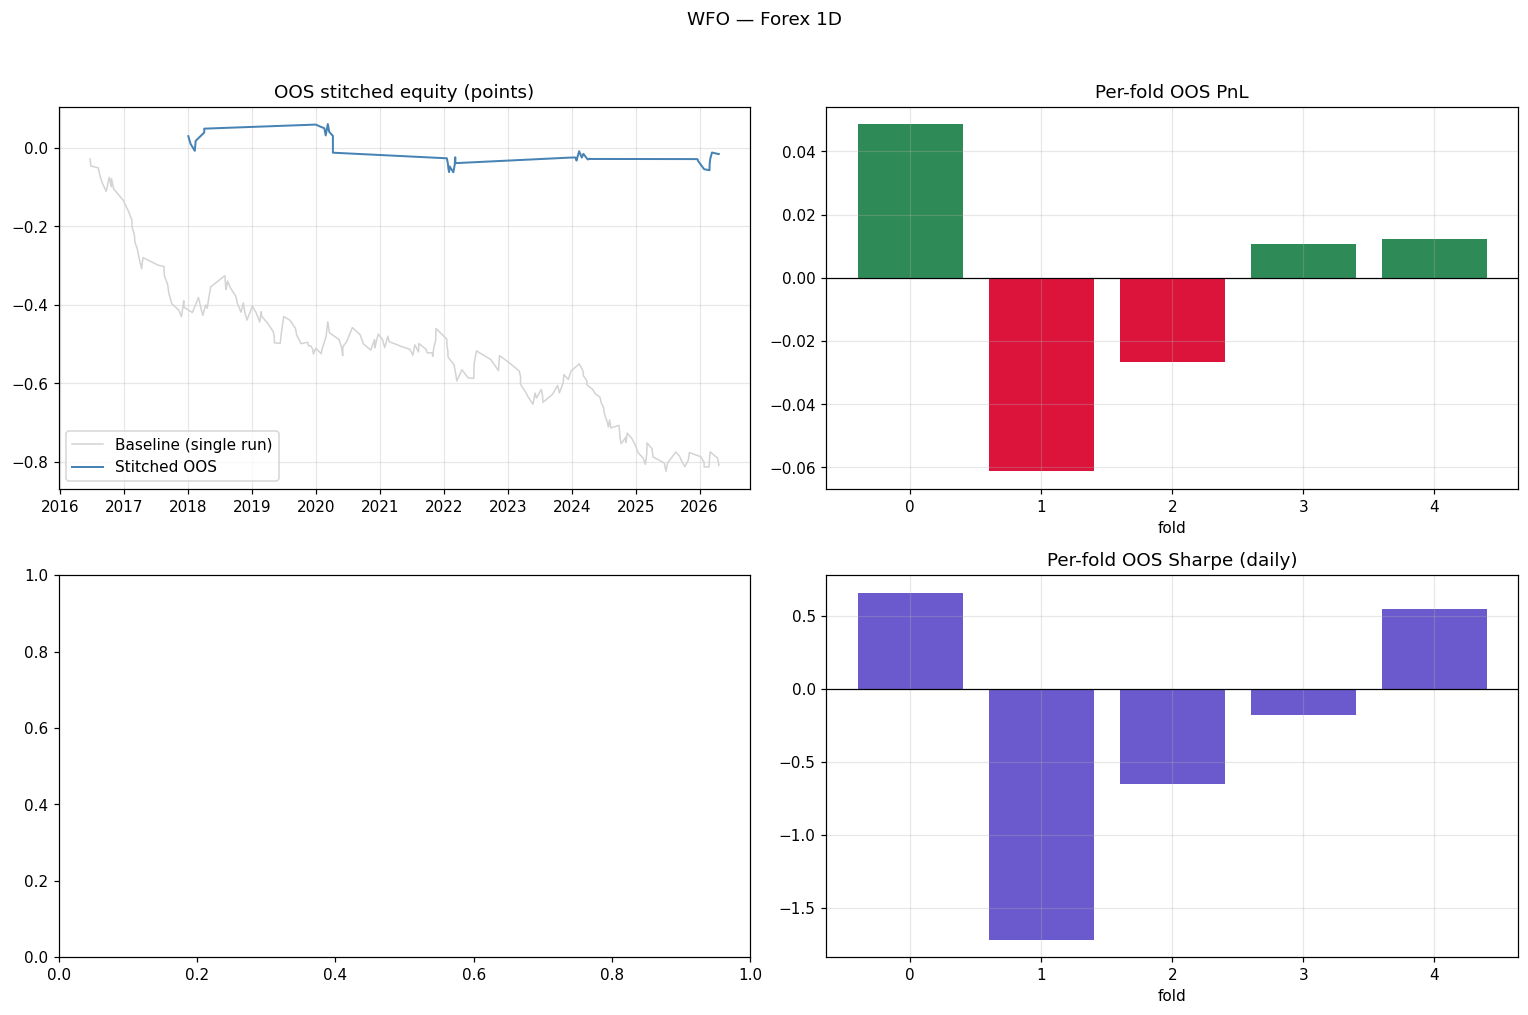

In [ ]:
forex_oos_portfolios = {
    tf: _PortfolioResult(wfo.oos_trades, wfo.oos_equity)
    for tf, wfo in wfo_combined["forex"].items()
    if not wfo.oos_trades.empty
}
print("OOS portfolio metrics — Forex (per timeframe):")
display(metrics_comparison(forex_oos_portfolios))

for tf, wfo in wfo_combined["forex"].items():
    if wfo.oos_trades.empty:
        continue
    baseline_eq = baseline_portfolio["forex"][tf].equity
    fig = plot_wfo_dashboard(wfo, full_equity=baseline_eq)
    fig.suptitle(f"WFO — Forex {tf}", y=1.02)
    plt.show()

### 4.2 B3 — WFO out-of-sample results

OOS portfolio metrics — B3 (per timeframe):


,1min,5min,15min,30min
num_trades,"8,585.0000","1,644.0000",510.0000,233.0000
total_pnl,"-27,928.2968","-15,747.1030","-16,018.9826","7,427.0391"
win_rate,0.4165,0.3996,0.4255,0.4549
profit_factor,0.9486,0.9338,0.8778,1.1022
expectancy,-3.2532,-9.5785,-31.4098,31.8757
max_drawdown,"-40,316.5047","-24,384.3970","-21,386.5605","-11,560.6521"
sharpe_daily,-0.6669,-0.3438,-0.3761,0.1535
sharpe_per_trade,-1.5015,-0.8644,-0.9646,0.4642
p_value,0.1332,0.3874,0.3348,0.6425


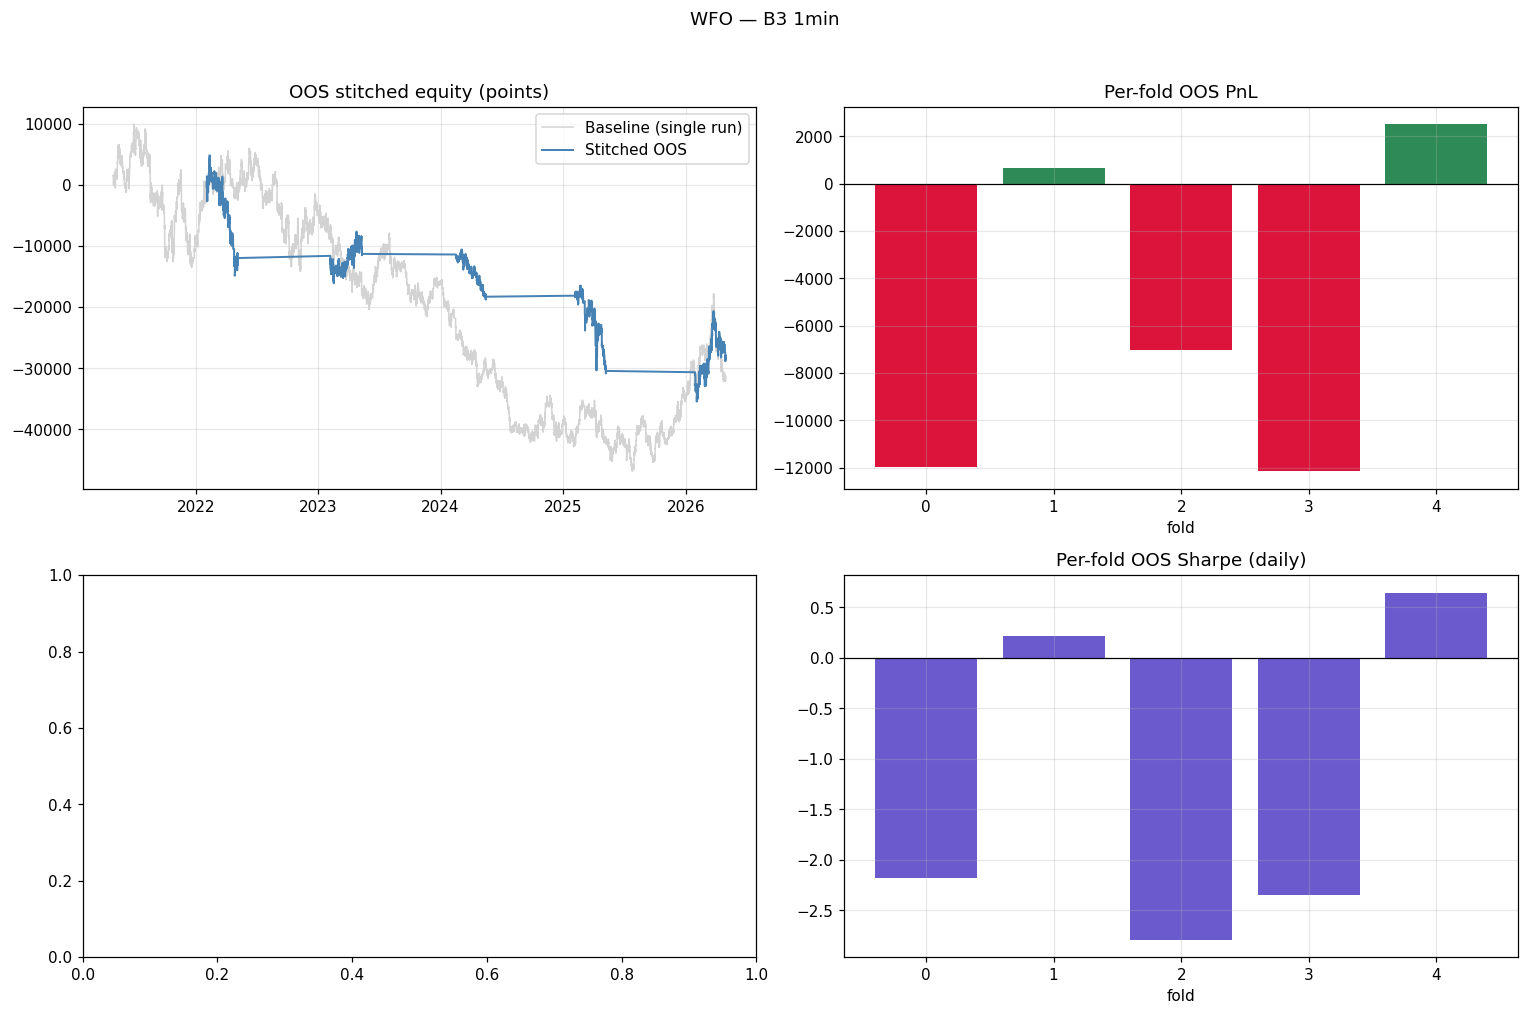

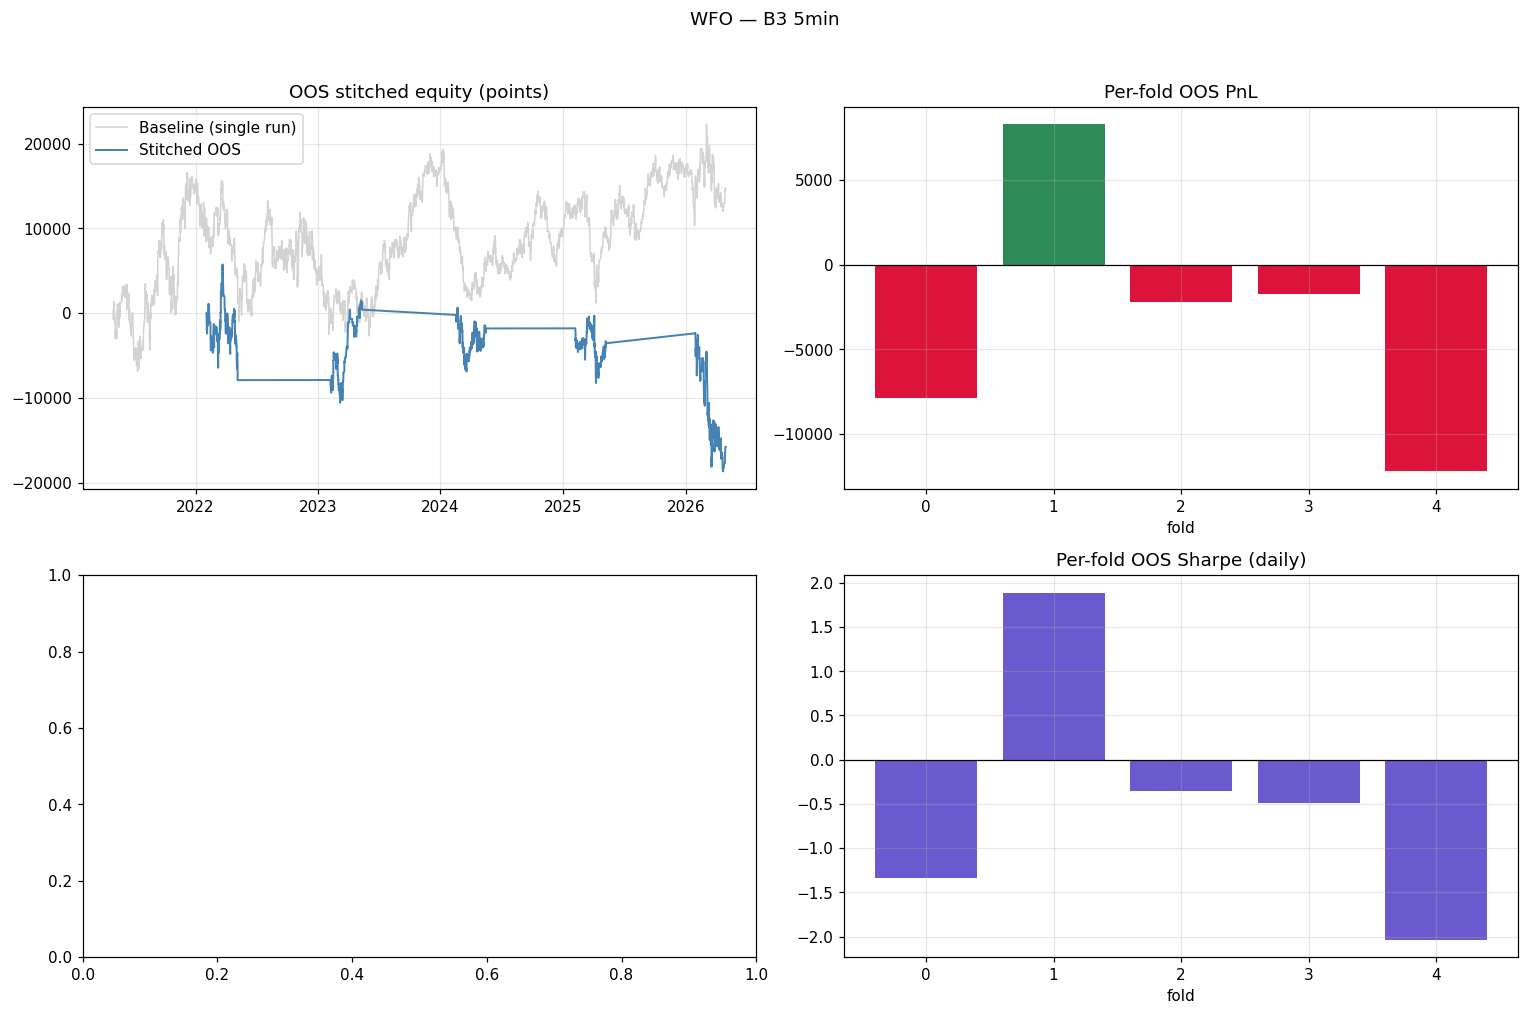

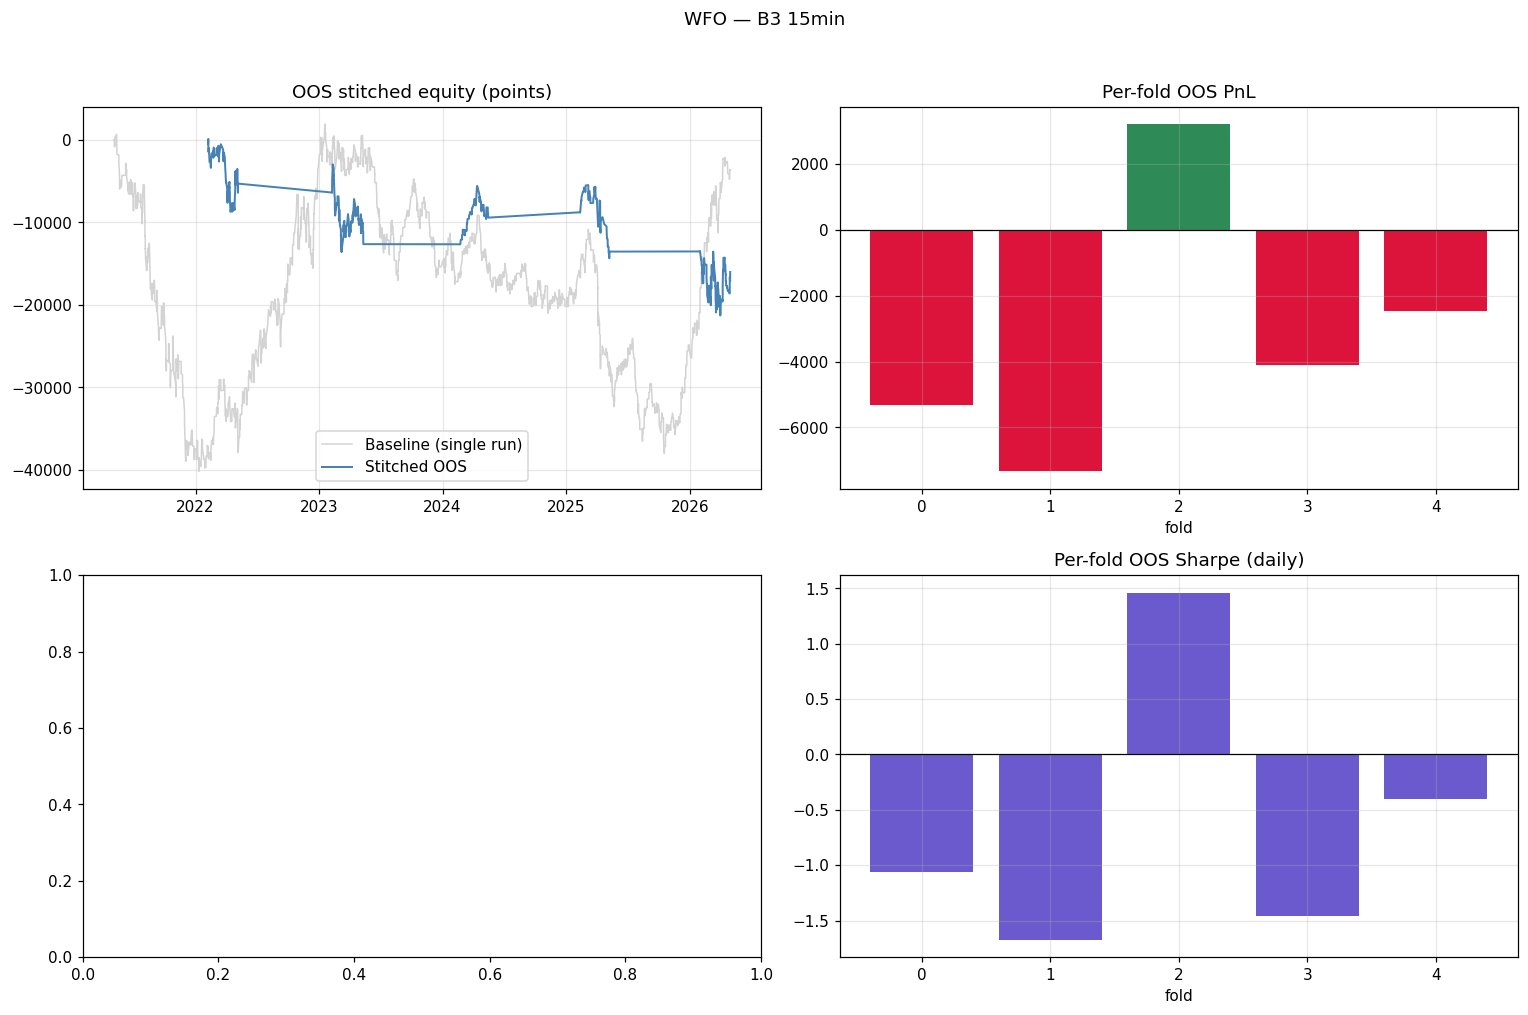

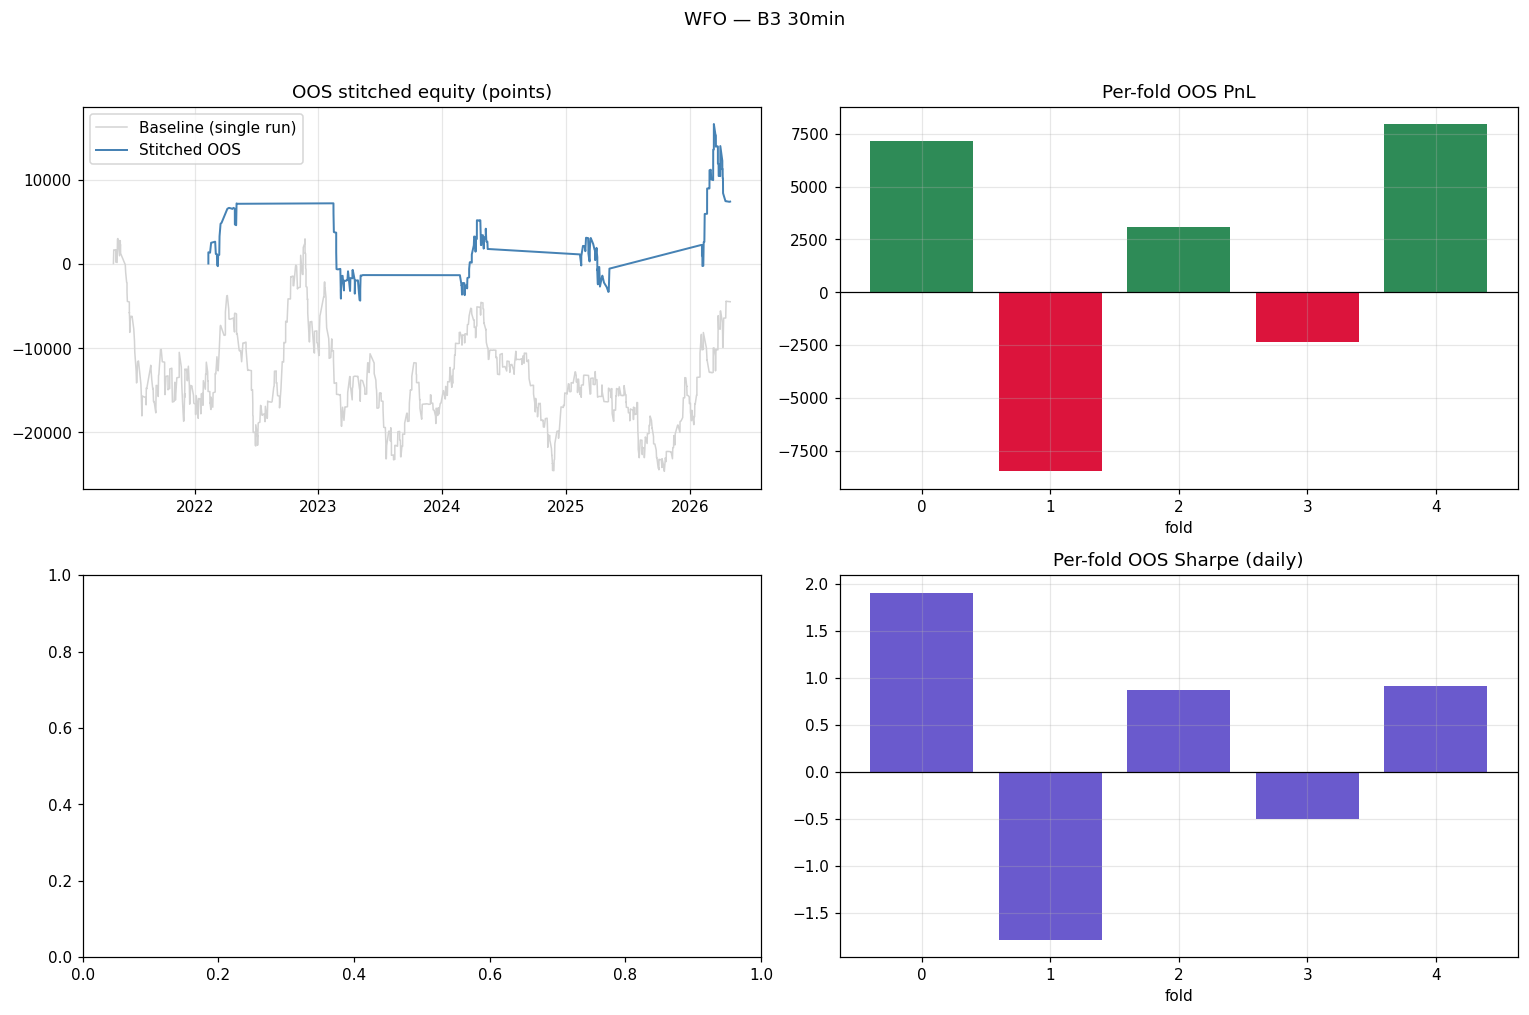

In [ ]:
b3_oos_portfolios = {
    tf: _PortfolioResult(wfo.oos_trades, wfo.oos_equity)
    for tf, wfo in wfo_combined["b3"].items()
    if not wfo.oos_trades.empty
}
print("OOS portfolio metrics — B3 (per timeframe):")
display(metrics_comparison(b3_oos_portfolios))

for tf, wfo in wfo_combined["b3"].items():
    if wfo.oos_trades.empty:
        continue
    baseline_eq = baseline_portfolio["b3"][tf].equity
    fig = plot_wfo_dashboard(wfo, full_equity=baseline_eq)
    fig.suptitle(f"WFO — B3 {tf}", y=1.02)
    plt.show()

### 4.3 WFO-optimized full-history backtest

For each (group, timeframe), pick the **most frequently selected** parameter
combination across WFO folds as the "best" params, then run a full-history
backtest with those params to see what the strategy would have produced with
consistently re-optimized values.

In [ ]:
def pick_best_params(wfo_windows, fallback):
    """Return the most common param combo across WFO folds as StrategyParams."""
    if wfo_windows.empty:
        return fallback
    pcols = [c for c in wfo_windows.columns if c.startswith("param_")]
    tuples = [tuple(row[c] for c in pcols) for _, row in wfo_windows.iterrows()]
    best = Counter(tuples).most_common(1)[0][0]
    kw = {c.replace("param_", ""): v for c, v in zip(pcols, best)}
    for k in ("fast", "slow", "atr_period"):
        if k in kw:
            kw[k] = int(kw[k])
    return StrategyParams(**kw)


optimized_params    = {}   # [group][tf][asset] = StrategyParams
optimized_portfolio = {}   # [group][tf]         = _PortfolioResult

for group, tfs in group_tfs.items():
    optimized_params[group]    = {}
    optimized_portfolio[group] = {}
    for tf, asset_dfs in tfs.items():
        optimized_params[group][tf] = {}
        per_asset_opt = {}
        for asset, df in asset_dfs.items():
            wfo = wfo_per_asset[group][tf][asset]
            params = pick_best_params(wfo.windows, baseline_params)
            optimized_params[group][tf][asset] = params
            per_asset_opt[asset] = Backtester(
                SMACrossoverStrategy(params), slippage_points=0.0
            ).run(df)
        optimized_portfolio[group][tf] = build_portfolio(per_asset_opt)

# Params chosen per (group, tf, asset)
print("Optimized parameters per group / timeframe / asset:")
for group in group_tfs:
    for tf in GROUP_TIMEFRAMES[group]:
        for asset, p in optimized_params[group][tf].items():
            print(f"  {group:5s} {tf:6s} {asset:8s}  "
                  f"fast={p.fast} slow={p.slow}  sl={p.sl_atr_mult} tp={p.tp_atr_mult}")

print("\nOptimized portfolio metrics — Forex:")
display(metrics_comparison(optimized_portfolio["forex"]))

print("\nOptimized portfolio metrics — B3:")
display(metrics_comparison(optimized_portfolio["b3"]))

Optimized parameters per group / timeframe / asset:
  forex 1h     EURCAD    fast=30 slow=100  sl=2.0 tp=4.0
  forex 1h     EURUSD    fast=10 slow=40  sl=1.5 tp=2.0
  forex 1h     GBPCHF    fast=10 slow=60  sl=2.0 tp=2.0
  forex 4h     EURCAD    fast=10 slow=40  sl=2.0 tp=3.0
  forex 4h     EURUSD    fast=20 slow=60  sl=1.5 tp=4.0
  forex 4h     GBPCHF    fast=10 slow=100  sl=3.0 tp=3.0
  forex 1D     EURCAD    fast=30 slow=40  sl=2.0 tp=2.0
  forex 1D     EURUSD    fast=30 slow=40  sl=1.5 tp=4.0
  forex 1D     GBPCHF    fast=10 slow=40  sl=1.5 tp=3.0
  b3    1min   WDO       fast=10 slow=100  sl=2.0 tp=3.0
  b3    1min   WIN       fast=20 slow=60  sl=3.0 tp=4.0
  b3    5min   WDO       fast=30 slow=60  sl=1.5 tp=2.0
  b3    5min   WIN       fast=30 slow=40  sl=2.0 tp=4.0
  b3    15min  WDO       fast=20 slow=100  sl=3.0 tp=3.0
  b3    15min  WIN       fast=30 slow=40  sl=1.5 tp=2.0
  b3    30min  WDO       fast=30 slow=60  sl=3.0 tp=4.0
  b3    30min  WIN       fast=30 slow=100  sl=2.

,1h,4h,1D
num_trades,"4,100.0000","1,128.0000",264.0000
total_pnl,-0.0347,0.2037,0.5229
win_rate,0.4249,0.3679,0.4280
profit_factor,0.9946,1.0492,1.2934
expectancy,-0.0000,0.0002,0.0020
max_drawdown,-0.4130,-0.4901,-0.2291
sharpe_daily,-0.0430,0.1664,0.4622
sharpe_per_trade,-0.1473,0.6961,1.7932
p_value,0.8829,0.4863,0.0729



Optimized portfolio metrics — B3:


,1min,5min,15min,30min
num_trades,"26,389.0000","6,998.0000","2,088.0000",699.0000
total_pnl,"-28,996.1339","34,010.9484","14,565.6709","7,228.6726"
win_rate,0.3767,0.4018,0.4531,0.4621
profit_factor,0.9854,1.0334,1.0295,1.0429
expectancy,-1.0988,4.8601,6.9759,10.3414
max_drawdown,"-66,689.5749","-38,410.4976","-25,629.8154","-34,333.4392"
sharpe_daily,-0.2806,0.3047,0.1969,0.1270
sharpe_per_trade,-0.7116,0.8632,0.5010,0.3480
p_value,0.4767,0.3880,0.6164,0.7278


## 5. Robustness

For each group, the timeframe with the highest OOS daily Sharpe (from Section 4)
is selected automatically for robustness testing.

1. **Monte-Carlo trade-order shuffling** — randomises the trade sequence 1 000 times
   to separate edge from sequencing luck; produces confidence bands for final PnL
   and max drawdown.
2. **Parameter sensitivity** — one-at-a-time sweeps around baseline params.
   A robust edge should degrade gradually, not fall off a cliff.

In [ ]:
def best_oos_tf(group):
    """Timeframe with the highest OOS daily Sharpe for the given group."""
    best_tf_name, best_sharpe = None, -np.inf
    for tf, wfo in wfo_combined[group].items():
        if wfo.oos_trades.empty:
            continue
        m = compute_metrics(_PortfolioResult(wfo.oos_trades, wfo.oos_equity))
        if m["sharpe_daily"] > best_sharpe:
            best_sharpe, best_tf_name = m["sharpe_daily"], tf
    return best_tf_name


best_tfs = {group: best_oos_tf(group) for group in group_tfs}
print("Best OOS timeframe selected per group (by daily Sharpe):")
for group, tf in best_tfs.items():
    print(f"  {group}: {tf}")

# Monte-Carlo on the best-TF optimized portfolio for each group
mc_results = {}
for group, tf in best_tfs.items():
    if tf is None:
        continue
    opt_trades = optimized_portfolio[group][tf].trades
    if opt_trades.empty:
        print(f"  {group} {tf}: no trades")
        continue
    print(f"\nMonte-Carlo — {group.upper()} {tf}  (n=1 000) ...")
    mc_results[group] = monte_carlo_trades(opt_trades, n_runs=1000, seed=42)
    summary = monte_carlo_summary(mc_results[group])
    print(pd.Series(summary).to_frame("value").to_string())

Best OOS timeframe selected per group (by daily Sharpe):
  forex: 4h
  b3: 30min

Monte-Carlo — FOREX 4h  (n=1 000) ...
                    value
mean_final_pnl     0.2037
median_final_pnl   0.2037
p05_final_pnl      0.2037
p95_final_pnl      0.2037
mean_max_drawdown -0.2564
p95_max_drawdown  -0.3837
prob_profitable    1.0000

Monte-Carlo — B3 30min  (n=1 000) ...
                         value
mean_final_pnl      7,228.6726
median_final_pnl    7,228.6726
p05_final_pnl       7,228.6726
p95_final_pnl       7,228.6726
mean_max_drawdown -20,370.9564
p95_max_drawdown  -29,974.7888
prob_profitable         1.0000


In [ ]:
variations = {
    "fast":        [10, 15, 20, 25, 30],
    "slow":        [30, 50, 80, 120],
    "sl_atr_mult": [1.0, 1.5, 2.0, 2.5, 3.0],
    "tp_atr_mult": [1.5, 2.0, 3.0, 4.0, 5.0],
}

sensitivity_results = {}
for group, tf in best_tfs.items():
    if tf is None:
        continue
    asset_dfs = group_tfs[group][tf]
    print(f"Parameter sensitivity — {group.upper()} {tf} ...")
    _rows = []
    for pname, values in variations.items():
        for v in values:
            _frames = []
            for asset, df in asset_dfs.items():
                params = StrategyParams(**{**baseline_params.as_dict(), pname: v})
                res = Backtester(SMACrossoverStrategy(params), slippage_points=0.0).run(df)
                if not res.trades.empty:
                    t = res.trades.copy()
                    t["asset"] = asset
                    _frames.append(t)
            if _frames:
                _ct = (
                    pd.concat(_frames, ignore_index=True)
                    .sort_values("exit_time")
                    .reset_index(drop=True)
                )
                _ceq = pd.Series(
                    _ct["pnl_points"].cumsum().values,
                    index=pd.to_datetime(_ct["exit_time"].values),
                )
                m = compute_metrics(_PortfolioResult(_ct, _ceq))
                _rows.append({"param": pname, "value": v, **m})
    sensitivity_results[group] = pd.DataFrame(_rows)
    print(f"  {len(sensitivity_results[group])} rows")

Parameter sensitivity — FOREX 4h ...


  19 rows
Parameter sensitivity — B3 30min ...
  19 rows


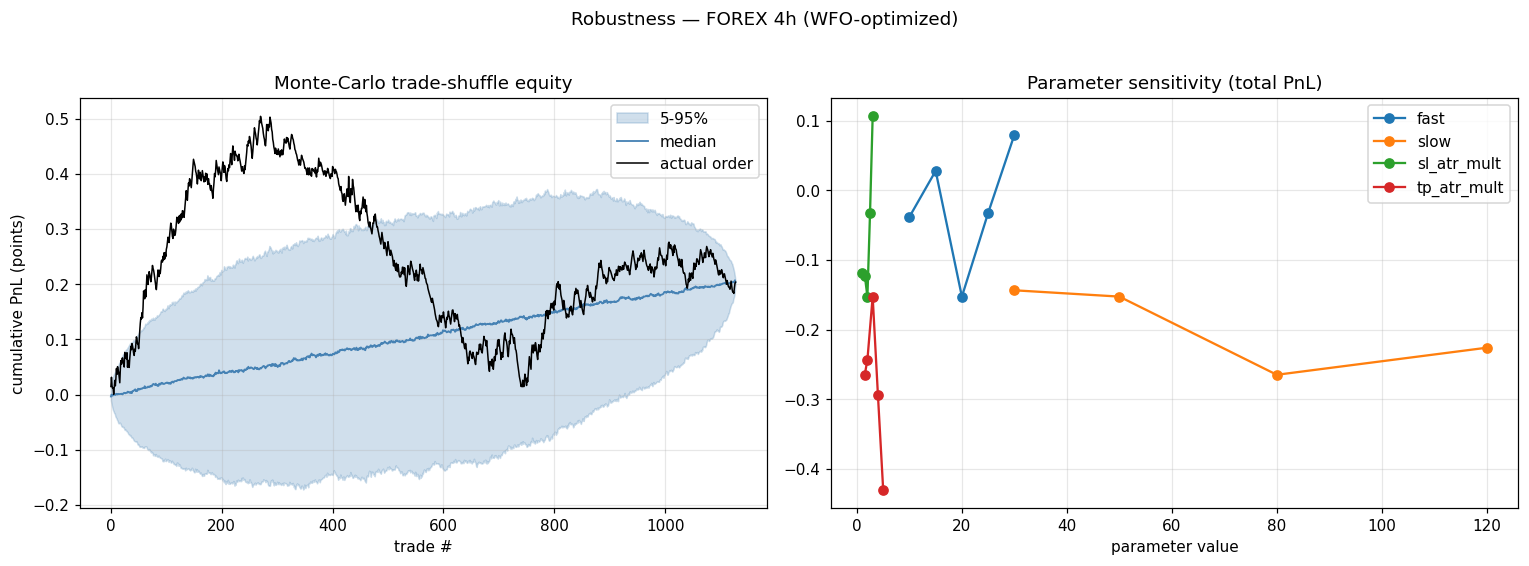

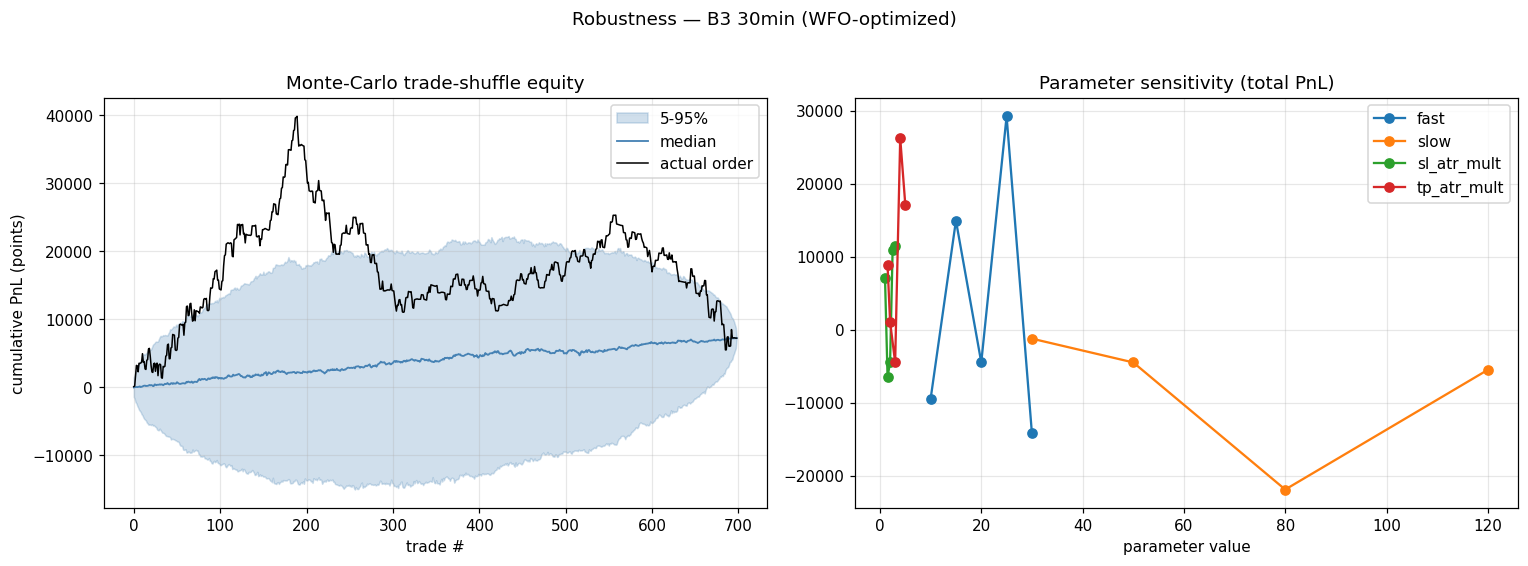

In [ ]:
for group, tf in best_tfs.items():
    if tf is None or group not in mc_results or group not in sensitivity_results:
        continue
    opt_trades = optimized_portfolio[group][tf].trades
    if opt_trades.empty:
        continue
    actual_equity = opt_trades["pnl_points"].cumsum().values
    fig = plot_robustness_dashboard(
        mc_results[group],
        baseline_equity=actual_equity,
        sensitivity=sensitivity_results[group],
    )
    fig.suptitle(f"Robustness — {group.upper()} {tf} (WFO-optimized)", y=1.02)
    plt.show()

## 6. Takeaways & next steps

**What this notebook gives us**
- A reproducible pipeline: load → multi-timeframe resample → baseline backtest → WFO →
  robustness, run **independently** for the Forex and B3 groups.
- Cross-timeframe comparison tables for each group so we can identify which horizon
  the strategy fits best.
- A concrete baseline to beat with more sophisticated strategies.

**Known simplifications** (intentional — next iterations, not bugs)
- Bar-close execution, no realistic fill modelling, unit sizing, no commissions.
- Intra-bar SL-before-TP assumption may under-state TP hits.
- WFO folds are fixed equal slices — anchored or expanding-window WFO is a natural
  follow-up.
- Per-asset independent parameter optimisation; joint portfolio optimisation
  across correlated assets is a natural extension.
- B3 futures are BRL-denominated — cross-group raw-point PnL comparison is not
  meaningful; normalise by a notional value or trade in percent-of-price before
  comparing the two groups.

**Obvious extensions**
- Session / time-of-day filters (especially relevant for B3's fixed trading hours).
- Volatility-scaled or fixed-fractional sizing per group.
- Classifier overlays in `machine_learning/`.
- Correlation-aware cross-asset position sizing within each group.